In [1]:
import numpy as np
import uproot
import awkward as ak
import hist

from pepper.misc import chunked_calls


def _maybe_sample(s, size, rng):
    if isinstance(s, uproot.model.Model) and s.classname.startswith("TH1"):
        values, edges = s.to_numpy()
        centers = (edges[1:] + edges[:-1]) / 2
        p = values / values.sum()
        s = rng.choice(centers, size, p=p)
    elif isinstance(s, (int, float)):
        s = np.full(size, s)
    elif isinstance(s, np.ndarray):
        s = s.reshape(size)
    return s


def _random_orthogonal(vec, rng):
    random = rng.random(vec.shape)
    rnorm = random / np.linalg.norm(random, axis=-1, keepdims=True)
    vnorm = vec / np.linalg.norm(vec, keepdims=True)
    u = rnorm - (rnorm * vnorm).sum(axis=-1, keepdims=True) * vnorm
    unorm = u / np.linalg.norm(u, keepdims=True)
    return unorm


def _rotate_axis(vec, axis, angle):
    # Taken from uproot_methods.TVector3
    # Using TVector3 directly led to many kinds of complications
    vx, vy, vz = np.rollaxis(vec, -1)
    ux, uy, uz = np.rollaxis(axis, -1)
    c = np.cos(angle)
    s = np.sin(angle)
    c1 = 1 - c

    x = ((c + ux**2 * c1) * vx
         + (ux * uy * c1 - uz * s) * vy
         + (ux * uz * c1 + uy * s) * vz)
    y = ((ux * uy * c1 + uz * s) * vx
         + (c + uy**2 * c1) * vy
         + (uy * uz * c1 - ux * s) * vz)
    z = ((ux * uz * c1 - uy * s) * vx
         + (uy * uz * c1 + ux * s) * vy
         + (c + uz**2 * c1) * vz)

    return np.stack([x, y, z], axis=-1)


def _smear(fourvec, energyf, alpha, num, rng):
    num_events = len(fourvec)
    e = np.asarray(fourvec.energy, dtype=np.float64)[:, None]
    p3 = np.stack(
        [
            np.asarray(fourvec.x, dtype=np.float64),
            np.asarray(fourvec.y, dtype=np.float64),
            np.asarray(fourvec.z, dtype=np.float64),
        ],
        axis=-1,
    )[:, None, :]
    m = np.asarray(fourvec.mass, dtype=np.float64)[:, None]
    #=======check============
    p2 = np.sum(p3**2, axis=-1)
    mass2_from_components = e**2 - p2
    sqrt_numerator = e**2 - m**2
    finite_input = (
        np.isfinite(e)
        & np.isfinite(m)
        & np.isfinite(p2)
        & np.isfinite(sqrt_numerator)
    )
    spacelike = mass2_from_components < 0
    negative_sqrt_argument = sqrt_numerator < 0
    zero_momentum = p2 <= 0

    bad = (
        ~finite_input
        | spacelike
        | negative_sqrt_argument
        | zero_momentum
    )

    #print(
    #    f"[SONN DEBUG]: "
    #    f"N={num_events}, "
    #    f"nonfinite={np.count_nonzero(~finite_input)}, "
    #    f"spacelike(E2-p2<0)={np.count_nonzero(spacelike)}, "
    #    f"negative(E2-m2)={np.count_nonzero(negative_sqrt_argument)}, "
    #    f"zero_p2={np.count_nonzero(zero_momentum)}"
    #)

    bad_indices = np.flatnonzero(bad[:, 0])[:5]

    #for i in bad_indices:
    #    print(
    #        f"event {i}: "
    #        f"E={e[i, 0]:.6g}, "
    #        f"m_property={m[i, 0]:.6g}, "
    #        f"|p|={np.sqrt(p2[i, 0]):.6g}, "
    #        f"E2-p2={mass2_from_components[i, 0]:.6g}, "
    #        f"E2-m2={sqrt_numerator[i, 0]:.6g}"
    #    )
    #===========================
    if num is None:
        return e, p3[..., 0], p3[..., 1], p3[..., 2]
    # Axes are [events, smearing, lorentz]
    e = np.broadcast_to(e, (num_events, num))
    p3 = np.broadcast_to(p3, (num_events, num, 3))
    m = np.broadcast_to(m, (num_events, num))
    
    if energyf is not None and num is not None:
        e = e * _maybe_sample(energyf, (num_events, num), rng)
        # Make sure e and m still have same dtype, otherwise numerical problems
        m = m.astype(e.dtype)
        # Cap energy to something bit above the mass
        np.clip(e, 1.01 * m, None, out=e)
    if alpha is not None and num is not None:
        # Rotate around a random orthogonal axis by alpha
        r = _random_orthogonal(p3, rng)
        p3 = _rotate_axis(p3, r, _maybe_sample(alpha, (num_events, num), rng))
    # Keep mass constant
    p3 = p3 * np.sqrt((e**2 - m**2) / (p3**2).sum(axis=-1))[..., None]

    return e, p3[..., 0], p3[..., 1], p3[..., 2]


def _roots_vectorized(poly, axis=-1):
    """Like numpy.roots just that it can take any number of axes, allowing to
    compute the roots of any number of polynomials at once"""
    if poly.ndim == 1:
        return np.roots(poly)
    # Bring input to two-dim shape
    poly = poly.swapaxes(axis, -1)
    shape = poly.shape
    poly = poly.reshape(-1, shape[-1])
    # Build companion matrix
    ones = np.ones(poly.shape[1] - 2, poly.dtype)
    companion = np.tile(np.diag(ones, -1), (poly.shape[0], 1, 1))
    companion[:, 0] = -poly[:, 1:] / poly[:, 0, None]
    # Find eigenvalues of companion matrix <=> Find roots of poly
    roots = np.linalg.eigvals(companion)
    num_roots = roots.shape[-1]
    # Bring roots to the original input shape
    roots = roots.reshape(shape[:-1] + (num_roots,)).swapaxes(-1, axis)

    return roots


def _lorvecfromnumpy(x, y, z, t, behavior, name="LorentzVector"):
    return ak.zip(
        {"x": x, "y": y, "z": z, "t": t}, with_name="LorentzVector",
        behavior=behavior)


def _from_regular(array, axis=1, **kwargs):
    """from_regular with multiple axis at once"""
    if isinstance(axis, int):
        return ak.from_regular(array, axis, **kwargs)
    for i in axis:
        array = ak.from_regular(array, i, **kwargs)
    return array


@chunked_calls("lep", True, 10000)
def sonnenschein(lep, antilep, b, antib, met, mwp=80.3, mwm=80.3, mt=172.5,
                 mat=172.5, num_smear=None, energyfl=None, energyfj=None,
                 alphal=None, alphaj=None, hist_mlb=None, rng=None):
    """Full kinematic reconstruction for dileptonic ttbar using Sonnenschein's
    method https://arxiv.org/pdf/hep-ph/0603011.pdf

    Parameters
    ----------
    lep
        Array holding one negativly charged lepton per event
    antilep
        Array holding one positively charged lepton per event
    b
        Array holding one negativly charged bottom quark per event
    antib
        Array holding one positively changed bottom quark per event
    met
        Array holding with one entry per event, yielding the MET pt and phi
    mwp
        Mass of the W+ boson. Either a number, an array with a
        number for each event or a histogram, to sample from
    mwm
        Same as ``mwp`` for the W- boson
    mt
        Same as ``mwp`` for the top quark
    mat
        Same as ``mwp`` for the top antiquark
    num_smear
        Number of times an event is smeared. If None, smearing is off
    energyfl
        Histogram in form of an uproot TH1 or numpy array giving Ereco/Egen
        for the leptons. If None, lepton energy won't be smeared
    energyfj
        Same as energyfl for bottom quarks
    alphal
        Histogram in form of an uproot TH1 or numpy array giving the angle
         between reco and gen leptons. If None, lepton angles won't be smeared
    alphaj
        Same as ``alphal`` for bottom quarks
    hist_mlb
        uproot TH1 of the lepton-bottom-quark-mass distribution.
        Is needed, if num_smear is not None
    rng
        A numpy.random.BitGenerator, if None a new one will be used
    """

    if rng is None:
        rng = np.random.default_rng()

    if lep.ndim > 1:
        # Get rid of jagged dimension, as we have one particle per row and
        # variable
        lep = ak.flatten(lep)
        antilep = ak.flatten(antilep)
        b = ak.flatten(b)
        antib = ak.flatten(antib)
        met = ak.flatten(met)

    # Allow num_smear to be 0
    if num_smear == 0:
        num_smear = None

    mat_input = mat
    mt_input = mt

    behav = lep.behavior
    # Use 2d numpy arrays. Use first axis for events, second for smearing
    num_events = len(lep)
    lE, lx, ly, lz = _smear(lep, energyfl, alphal, num_smear, rng)
    alE, alx, aly, alz = _smear(antilep, energyfl, alphal, num_smear, rng)
    bE, bx, by, bz = _smear(b, energyfj, alphaj, num_smear, rng)
    abE, abx, aby, abz = _smear(antib, energyfj, alphaj, num_smear, rng)
    # Even if num_smear is None, we have a smear axis. Update num_smear
    num_smear = max(lE.shape[1], bE.shape[1])  #need to find the factor
    # Unpack MET compontents and also propagate smearing to it
    METx = (met.x[:, None] - lx + lep.x[:, None] - alx + antilep.x[:, None]
                           - bx + b.x[:, None] - abx + antib.x[:, None])
    METx = np.asarray(METx)
    METy = (met.y[:, None] - ly + lep.y[:, None] - aly + antilep.y[:, None]
                           - by + b.y[:, None] - aby + antib.y[:, None])
    METy = np.asarray(METy)

    mwp = _maybe_sample(mwp, (num_events, num_smear), rng)
    mwm = _maybe_sample(mwm, (num_events, num_smear), rng)
    mat = _maybe_sample(mat, (num_events, num_smear), rng)
    mt = _maybe_sample(mt, (num_events, num_smear), rng)
    # Compute masses, make sure they are real
    lp = np.sqrt(lx**2 + ly**2 + lz**2)
    lE = np.where(lE < lp, lp, lE)
    ml = np.sqrt(lE**2 - lp**2)
    alp = np.sqrt(alx**2 + aly**2 + alz**2)
    alE = np.where(alE < alp, alp, alE)
    mal = np.sqrt(alE**2 - alp**2)
    bp = np.sqrt(bx**2 + by**2 + bz**2)
    bE = np.where(bE < bp, bp, bE)
    mb = np.sqrt(bE**2 - bp**2)
    abp = np.sqrt(abx**2 + aby**2 + abz**2)
    abE = np.where(abE < abp, abp, abE)
    mab = np.sqrt(abE**2 - abp**2)
    del lp, alp, bp, abp

    if hist_mlb is not None:
        mlab = np.sqrt((lE + abE)**2 - (lx + abx)**2
                       - (ly + aby)**2 - (lz + abz)**2)
        malb = np.sqrt((alE + bE)**2 - (alx + bx)**2
                       - (aly + by)**2 - (alz + bz)**2)
        # Set over and underflow to 0
        values, edges = hist_mlb.to_numpy(flow=True)
        values = np.r_[0, values[1:-1], 0]
        plab = values[np.digitize(mlab, edges) - 1]
        palb = values[np.digitize(malb, edges) - 1]
        weights = plab * palb

    elif num_smear is not None and num_smear > 1:
        raise ValueError("Smearing is enabled but got None for hist_mlb")
    else:
        weights = np.ones_like(lE)

    a1 = ((bE + alE) * (mwp ** 2 - mal ** 2)
          - alE * (mt ** 2 - mb ** 2 - mal ** 2) + 2 * bE * alE ** 2
          - 2 * alE * (bx * alx + by * aly + bz * alz))
    del mb
    a2 = 2 * (bE * alx - alE * bx)
    a3 = 2 * (bE * aly - alE * by)
    a4 = 2 * (bE * alz - alE * bz)

    b1 = ((abE + lE) * (mwm ** 2 - ml ** 2)
          - lE * (mat ** 2 - mab ** 2 - ml ** 2) + 2 * abE * lE ** 2
          - 2 * lE * (abx * lx + aby * ly + abz * lz))
    del mab
    b2 = 2 * (abE * lx - lE * abx)
    b3 = 2 * (abE * ly - lE * aby)
    b4 = 2 * (abE * lz - lE * abz)

    c00 = (- 4 * (alE ** 2 - aly ** 2) - 4 * (alE ** 2 - alz ** 2)
           * (a3 / a4) ** 2 - 8 * aly * alz * a3 / a4)
    c10 = (- 8 * (alE ** 2 - alz ** 2) * a2 * a3 / (a4 ** 2) + 8 * alx * aly
           - 8 * alx * alz * a3 / a4 - 8 * aly * alz * a2 / a4)
    c11 = (4 * (mwp ** 2 - mal ** 2) * (aly - alz * a3 / a4)
           - 8 * (alE ** 2 - alz ** 2) * a1 * a3 / (a4 ** 2)
           - 8 * aly * alz * a1 / a4)
    c20 = (- 4 * (alE ** 2 - alx ** 2) - 4 * (alE ** 2 - alz ** 2)
           * (a2 / a4) ** 2 - 8 * alx * alz * a2 / a4)
    c21 = (4 * (mwp ** 2 - mal ** 2) * (alx - alz * a2 / a4)
           - 8 * (alE ** 2 - alz ** 2) * a1 * a2 / (a4 ** 2)
           - 8 * alx * alz * a1 / a4)
    c22 = ((mwp ** 2 - mal ** 2) ** 2 - 4 * (alE ** 2 - alz ** 2)
           * (a1 / a4) ** 2 - 4 * (mwp ** 2 - mal ** 2) * alz * a1 / a4)
    del mal

    d00 = (- 4 * (lE ** 2 - ly ** 2) - 4 * (lE ** 2 - lz ** 2)
           * (b3 / b4) ** 2 - 8 * ly * lz * b3 / b4)
    d10 = (- 8 * (lE ** 2 - lz ** 2) * b2 * b3 / (b4 ** 2)
           + 8 * lx * ly - 8 * lx * lz * b3 / b4 - 8 * ly * lz * b2 / b4)
    d11p = (4 * (mwm ** 2 - ml ** 2) * (ly - lz * b3 / b4)
            - 8 * (lE ** 2 - lz ** 2) * b1 * b3 / (b4 ** 2)
            - 8 * ly * lz * b1 / b4)
    d20 = (- 4 * (lE ** 2 - lx ** 2) - 4 * (lE ** 2 - lz ** 2)
           * (b2 / b4) ** 2 - 8 * lx * lz * b2 / b4)
    d21p = (4 * (mwm ** 2 - ml ** 2) * (lx - lz * b2 / b4)
            - 8 * (lE ** 2 - lz ** 2) * b1 * b2 / (b4 ** 2)
            - 8 * lx * lz * b1 / b4)
    d22p = ((mwm ** 2 - ml ** 2) ** 2 - 4 * (lE ** 2 - lz ** 2)
            * (b1 / b4) ** 2 - 4 * (mwm ** 2 - ml ** 2) * lz * b1 / b4)
    del ml

    d11 = - d11p - 2 * METy * d00 - METx * d10
    d21 = - d21p - 2 * METx * d20 - METy * d10
    d22 = (d22p + METx ** 2 * d20 + METy ** 2 * d00
           + METx * METy * d10 + METx * d21p + METy * d11p)

    h0 = (c00 ** 2 * d20 ** 2 + c10 * d20 * (c10 * d00 - c00 * d10)
          + c20 * d10 * (c00 * d10 - c10 * d00)
          + c20 * d00 * (c20 * d00 - 2 * c00 * d20))
    h1 = (c00 * d21 * (2 * c00 * d20 - c10 * d10)
          - c00 * d20 * (c11 * d10 + c10 * d11)
          + c00 * d10 * (2 * c20 * d11 + c21 * d10)
          - 2 * c00 * d00 * (c21 * d20 + c20 * d21)
          + c10 * d00 * (2 * c11 * d20 + c10 * d21)
          + c20 * d00 * (2 * c21 * d00 - c10 * d11)
          - d00 * d10 * (c11 * c20 + c10 * c21))
    # (note the sign of c20*d00*(...) is different to the appendix of
    # Sonnenschein's paper, and instead follows the implementation on github:
    # https://github.com/gerbaudo/ttbar-kinsol-comp,
    # which gives the right solution)

    h2 = (c00 ** 2 * (2 * d22 * d20 + d21 ** 2)
          - c00 * d21 * (c11 * d10 + c10 * d11)
          + c11 * d20 * (c11 * d00 - c00 * d11)
          + c00 * d10 * (c22 * d10 - c10 * d22)
          + c00 * d11 * (2 * c21 * d10 + c20 * d11)
          + (2 * c22 * c20 + c21 ** 2) * d00 ** 2
          - 2 * c00 * d00 * (c22 * d20 + c21 * d21 + c20 * d22)
          + c10 * d00 * (2 * c11 * d21 + c10 * d22)
          - d00 * d10 * (c11 * c21 + c10 * c22)
          - d00 * d11 * (c11 * c20 + c10 * c21))
    h3 = (c00 * d21 * (2 * c00 * d22 - c11 * d11)
          + c00 * d11 * (2 * c22 * d10 + c21 * d11)
          + c22 * d00 * (2 * c21 * d00 - c11 * d10)
          - c00 * d22 * (c11 * d10 + c10 * d11)
          - 2 * c00 * d00 * (c22 * d21 + c21 * d22)
          - d00 * d11 * (c11 * c21 + c10 * c22)
          + c11 * d00 * (c11 * d21 + 2 * c10 * d22))
    h4 = (c00 ** 2 * d22 ** 2 + c11 * d22 * (c11 * d00 - c00 * d11)
          + c00 * c22 * (d11 ** 2 - 2 * d00 * d22)
          + c22 * d00 * (c22 * d00 - c11 * d11))
    h = np.stack([h0, h1, h2, h3, h4], axis=-1)

    roots = _roots_vectorized(h)
    del h0, h1, h2, h3, h4, h
    vpx = roots.real
    is_real = abs(roots.imag) < 10 ** -6
    del roots

    c0 = c00[..., None]
    c1 = c10[..., None] * vpx + c11[..., None]
    c2 = c20[..., None] * vpx ** 2 + c21[..., None] * vpx + c22[..., None]
    d0 = d00[..., None]
    d1 = d10[..., None] * vpx + d11[..., None]
    d2 = d20[..., None] * vpx ** 2 + d21[..., None] * vpx + d22[..., None]

    vpy = (c0 * d2 - c2 * d0)/(c1 * d0 - c0 * d1)
    vpz = ((-a1[..., None] - a2[..., None] * vpx - a3[..., None] * vpy)
           / a4[..., None])
    vbarpx = METx[..., None] - vpx
    vbarpy = METy[..., None] - vpy
    vbarpz = ((-b1[..., None] - b2[..., None] * vbarpx - b3[..., None]
               * vbarpy) / b4[..., None])

    # Neutrino mass is assumed to be 0
    vE = np.sqrt(vpx ** 2 + vpy ** 2 + vpz ** 2)
    vbarE = np.sqrt(vbarpx ** 2 + vbarpy ** 2 + vbarpz ** 2)

    is_real = _from_regular(is_real, axis=(1, 2))
    v = _lorvecfromnumpy(vpx, vpy, vpz, vE, behav)[is_real]
    av = _lorvecfromnumpy(vbarpx, vbarpy, vbarpz, vbarE, behav)[is_real]
    b = _lorvecfromnumpy(bx, by, bz, bE, behav)
    ab = _lorvecfromnumpy(abx, aby, abz, abE, behav)
    lep = _lorvecfromnumpy(lx, ly, lz, lE, behav)
    alep = _lorvecfromnumpy(alx, aly, alz, alE, behav)
    wp = v + alep
    wm = av + lep
    t = wp + b
    at = wm + ab

    # Reduce solution axis and pick the solution with the smallest mtt
    # Note that there is a very small probability of having a weight of zero
    # and a root that looks real, we don't want these
    has_solution = ak.any(is_real, axis=2) & (weights != 0)
    min_mtt = ak.argmin((t + at).mass, axis=2, keepdims=True)
    t = ak.flatten(t[min_mtt][has_solution], axis=2)
    at = ak.flatten(at[min_mtt][has_solution], axis=2)
    weights = _from_regular(weights, axis=1)[has_solution]

    # Undo smearing by averaging, slice with has_solution again to not get
    # vectors with zeros if there is no solution
    sum_weights = ak.where(ak.num(weights) > 0, ak.sum(weights, axis=1), 1.)
    has_solution = ak.any(has_solution, axis=1, keepdims=True)

    t = ak.drop_none(ak.mask(ak.zip(
        {f: ak.sum(t[f] * weights, axis=1, keepdims=True) for f in t.fields},
        with_name="LorentzVector"), has_solution)) / sum_weights
    at = ak.drop_none(ak.mask(ak.zip(
        {f: ak.sum(at[f] * weights, axis=1, keepdims=True) for f in at.fields},
        with_name="LorentzVector"), has_solution)) / sum_weights

    # Top mass got changed by the averaging. Set to input mass again
    # ... but only if the top mass is fixed and not smeared
    if isinstance(mt_input, (int, float)):
        t["t"] = np.sqrt(mt_input ** 2 + t.p2)
    if isinstance(mat_input, (int, float)):
        at["t"] = np.sqrt(mat_input ** 2 + at.p2)

    return t, at


def _mtt_sonn_partition(
    lep0,
    lep1,
    b0,
    b1,
    met,
    h_mbl,
    h_mW,
):
    if ak.backend(lep0) == "typetracer":
        return _MTT_SONN_META
    if h_mbl is None:
        raise ValueError(
            "_mtt_sonn_partition requires a materialized h_mbl histogram"
        )

    # From here, the inputs are real, materialized Awkward arrays.
    if len(lep0) == 0:
        return ak.Array(np.empty(0, dtype=np.float64))

    # Veto events whose original input four-vectors cannot be safely rescaled:
    #   - NaN or infinite E, px, py, pz, mass, or derived quantities;
    #   - non-positive energy or zero momentum;
    #   - a genuinely spacelike four-vector, E^2 - |p|^2 < 0;
    #   - E^2 - m^2 < 0, which would make the momentum-rescaling
    #     sqrt((E^2 - m^2) / |p|^2) undefined.
    # A small numerical tolerance is used, so tiny negative values caused only
    # by floating-point precision are retained rather than vetoed.
    # This is an input-quality veto only very small fraction have been vetoed by this
    def valid_for_smear(obj):
        e = np.asarray(obj.energy, dtype=np.float64)
        px = np.asarray(obj.x, dtype=np.float64)
        py = np.asarray(obj.y, dtype=np.float64)
        pz = np.asarray(obj.z, dtype=np.float64)
        m = np.asarray(obj.mass, dtype=np.float64)
    
        p2 = px**2 + py**2 + pz**2
        mass2_from_components = e**2 - p2
        sqrt_numerator = e**2 - m**2

        scale = np.maximum(
            e**2 + p2 + m**2,
            1.0,
        )
        tolerance = 1.0e-12 * scale
    
        return (
            np.isfinite(e)
            & np.isfinite(px)
            & np.isfinite(py)
            & np.isfinite(pz)
            & np.isfinite(m)
            & np.isfinite(p2)
            & np.isfinite(mass2_from_components)
            & np.isfinite(sqrt_numerator)
            & (e > 0.0)
            & (p2 > 0.0)
            & (mass2_from_components >= -tolerance)
            & (sqrt_numerator >= -tolerance)
        )

    valid_event = (
        valid_for_smear(lep0)
        & valid_for_smear(lep1)
        & valid_for_smear(b0)
        & valid_for_smear(b1)
        & np.isfinite(np.asarray(met.x, dtype=np.float64))
        & np.isfinite(np.asarray(met.y, dtype=np.float64))
    )

    n_vetoed = np.count_nonzero(~valid_event)

    if n_vetoed > 0:
        print(
         f"[SONN INPUT VETO] Removed {n_vetoed}/{len(valid_event)} "
         "events with invalid input for the _smear square root"
         )

    lep0 = lep0[valid_event]
    lep1 = lep1[valid_event]
    b0 = b0[valid_event]
    b1 = b1[valid_event]
    met = met[valid_event]

    if len(lep0) == 0:
        return ak.Array(np.empty(0, dtype=np.float64))

    n_trials = 100
    rng = np.random.default_rng(12345)

    jet_energy_factors = rng.normal(
        loc=1.0,
        scale=0.10,
        size=(len(lep0), n_trials),
    )

    #mwp_trials = rng.uniform(
    #    low=70.0,
    #    high=90.0,
    #    size=(len(lep0), n_trials),
    #)

    #mwm_trials = rng.uniform(
    #    low=70.0,
    #    high=90.0,
    #    size=(len(lep0), n_trials),
    #)

    top0, top1 = sonnenschein(
        lep=lep1,
        antilep=lep0,
        b=b0,
        antib=b1,
        met=met,

        mwp=h_mW,
        mwm=h_mW,

        mt=172.5,
        mat=172.5,

        num_smear=n_trials,
        energyfl=None,
        energyfj=jet_energy_factors,
        alphal=None,
        alphaj=None,
        hist_mlb=h_mbl,
        rng=rng,
    )

    mtt = ak.flatten(
        (top0 + top1).mass,
        axis=None,
    )

    return ak.values_astype(mtt, np.float64)


_MTT_SONN_META = ak.Array(
    ak.to_layout(
        np.empty(0, dtype=np.float64)
    ).to_typetracer(forget_length=True)
)

if __name__ == '__main__':
    from coffea.nanoevents.methods import vector
    # test case:
    lep = ak.Array({
        "t": [165.33320], "x": [26.923591], "y": [16.170616],
        "z": [-162.3227]}, with_name="LorentzVector", behavior=vector.behavior)
    antilep = ak.Array({
        "t": [49.290821], "x": [-34.58441], "y": [-13.27824],
        "z": [-32.51431]}, with_name="LorentzVector", behavior=vector.behavior)
    b = ak.Array({
        "t": [205.54469], "x": [99.415420], "y": [-78.89404],
        "z": [-161.6102]}, with_name="LorentzVector", behavior=vector.behavior)
    antib = ak.Array({
        "t": [362.82086], "x": [-49.87086], "y": [91.930526],
        "z": [-347.3868]}, with_name="LorentzVector", behavior=vector.behavior)
    nu = ak.Array({
        "t": [70.848953], "x": [34.521587], "y": [-51.23474],
        "z": [-6.555319]}, with_name="LorentzVector", behavior=vector.behavior)
    antinu = ak.Array({
        "t": [13.760989], "x": [11.179965], "y": [-3.844941],
        "z": [7.0419898]}, with_name="LorentzVector", behavior=vector.behavior)
    sump4 = nu + antinu
    met = ak.Array({
        "pt": sump4.pt, "eta": [0.], "phi": sump4.phi, "mass": [0.]},
        with_name="PtEtaPhiMLorentzVector", behavior=vector.behavior)
    top, antitop = sonnenschein(lep, antilep, b, antib, met)
    print("MC Truth:", (antilep + nu + b)[0],
                       (lep + antinu + antib)[0])
    print("Reconstructed:", top, antitop)
    # Reconstructed: [{x: 93.5, y: -160, z: -213, t: 331}]
    #                [{x: -5.88, y: 121, z: -508, t: 550}]

    import time
    n = 10000
    lep = ak.Array({
        "t": np.full(n, 165.33320), "x": np.full(n, 26.923591),
        "y": np.full(n, 16.170616), "z": np.full(n, -162.3227)},
        with_name="LorentzVector", behavior=vector.behavior)
    antilep = ak.Array({
        "t": np.full(n, 49.290821), "x": np.full(n, -34.58441),
        "y": np.full(n, -13.27824), "z": np.full(n, -32.51431)},
        with_name="LorentzVector", behavior=vector.behavior)
    b = ak.Array({
        "t": np.full(n, 205.54469), "x": np.full(n, 99.415420),
        "y": np.full(n, -78.89404), "z": np.full(n, -161.6102)},
        with_name="LorentzVector", behavior=vector.behavior)
    antib = ak.Array({
        "t": np.full(n, 362.82086), "x": np.full(n, -49.87086),
        "y": np.full(n, 91.930526), "z": np.full(n, -347.3868)},
        with_name="LorentzVector", behavior=vector.behavior)
    nu = ak.Array({
        "t": np.full(n, 70.848953), "x": np.full(n, 34.521587),
        "y": np.full(n, -51.23474), "z": np.full(n, -6.555319)},
        with_name="LorentzVector", behavior=vector.behavior)
    antinu = ak.Array({
        "t": np.full(n, 13.760989), "x": np.full(n, 11.179965),
        "y": np.full(n, -3.844941), "z": np.full(n, 7.0419898)},
        with_name="LorentzVector", behavior=vector.behavior)
    sump4 = nu + antinu
    met = ak.Array({
        "pt": sump4.pt, "eta": np.zeros(n), "phi": sump4.phi,
        "mass": np.zeros(n)}, with_name="PtEtaPhiMLorentzVector",
        behavior=vector.behavior)

    t = time.time()
    sonnenschein(lep, antilep, b, antib, met)
    print("Took {} s for {} events".format(time.time() - t, n))


MC Truth: {x: 99.4, y: -143, z: -201, t: 326} {x: -11.8, y: 104, z: -503, t: 542}
Reconstructed: [[{x: 93.5, y: -160, z: -213, t: 331}]] [[{x: -5.88, y: 121, z: -508, t: 550}]]
Took 0.11028242111206055 s for 10000 events


In [2]:
import hist
import dask
import hist.dask as hda
import awkward as ak
import numpy as np
import dask_awkward as dak
from functools import partial

from hist import axis, storage

from coffea import processor
from coffea.nanoevents.methods import candidate
from coffea.nanoevents.methods import vector as vec


def make_match_p4(obj):
    """Minimal p4 used only for delta-R matching."""
    return ak.zip(
        {
            "pt": ak.fill_none(obj.pt, 0.0),
            "eta": ak.fill_none(obj.eta, 0.0),
            "phi": ak.fill_none(obj.phi, 0.0),
            "mass": ak.fill_none(
                getattr(obj, "mass", ak.zeros_like(obj.pt)),
                0.0,
            ),
            "charge": ak.zeros_like(obj.pt),
        },
        with_name="PtEtaPhiMCandidate",
        behavior=candidate.behavior,
    )


def match_b_to_a(a_obj, b_obj, match_dr):
    """
    Match every object in ``a_obj`` to the closest object in ``b_obj``
    within the same event.

    Both inputs must have shape::

        events * variable number of objects

    The outputs also have exactly that shape.  Invalid matches are removed
    from the object axis, while the event axis is always preserved.
    """
    a_p4 = make_match_p4(a_obj)
    b_p4 = make_match_p4(b_obj)

    a_for_match = ak.zip(
        {"obj": a_obj, "p4": a_p4},
        depth_limit=2,
    )
    b_for_match = ak.zip(
        {"obj": b_obj, "p4": b_p4},
        depth_limit=2,
    )

    pairs = ak.cartesian(
        {"a": a_for_match, "b": b_for_match},
        axis=1,
        nested=True,
    )

    dr = pairs.a.p4.delta_r(pairs.b.p4)

    min_dr = ak.min(
        dr,
        axis=2,
        keepdims=True,
        mask_identity=True,
    )

    is_closest = ak.fill_none(dr == min_dr, False)

    closest_b = ak.firsts(
        ak.drop_none(
            ak.mask(pairs.b.obj, is_closest),
            axis=2,
        ),
        axis=2,
    )

    closest_dr = ak.firsts(
        ak.drop_none(
            ak.mask(dr, is_closest),
            axis=2,
        ),
        axis=2,
    )

    valid = ak.fill_none(closest_dr < match_dr, False)
    
    matched_a = ak.drop_none(
        ak.mask(a_obj, valid),
        axis=1,
    )
    matched_b = ak.drop_none(
        ak.mask(closest_b, valid),
        axis=1,
    )
    matched_dr = ak.drop_none(
        ak.mask(closest_dr, valid),
        axis=1,
    )

    return matched_a, matched_b, matched_dr

def has_exactly_two_distinct(keys):
    """Return one Boolean per event: exactly two entries with different keys."""
    key_pairs = ak.combinations(
        keys,
        2,
        fields=["left", "right"],
        axis=1,
    )

    pair_is_distinct = ak.all(
        key_pairs.left != key_pairs.right,
        axis=1,
        mask_identity=False,
    )

    return ak.fill_none(
        (ak.num(keys, axis=1) == 2) & pair_is_distinct,
        False,
        axis=None,
    )

def make_p4(obj):
    return ak.zip(
        {
            "pt": obj.pt,
            "eta": obj.eta,
            "phi": obj.phi,
            "mass": obj.mass,
        },
        with_name="PtEtaPhiMLorentzVector",
        behavior=vec.behavior,
    )
    
def make_xyzt_p4(obj):
    # Convert before doing any arithmetic.
    pt = ak.values_astype(obj.pt, np.float64)
    eta = ak.values_astype(obj.eta, np.float64)
    phi = ak.values_astype(obj.phi, np.float64)
    mass = ak.values_astype(obj.mass, np.float64)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)

    p2 = px**2 + py**2 + pz**2
    energy = np.sqrt(p2 + mass**2)

    return ak.zip(
        {
            "x": px,
            "y": py,
            "z": pz,
            "t": energy,
        },
        with_name="LorentzVector",
        behavior=vec.behavior,
    )


class MyProcessor(processor.ProcessorABC):
    def __init__(self):
        pass

    def process(self, events):
        mass_axis = axis.Regular(
            100,
            0,
            15000,
            name="mass",
            label="Mass [GeV]",
        )

        h_mSuu = hda.Hist(mass_axis, storage=storage.Weight())
        h_mtt_rec = hda.Hist(mass_axis, storage=storage.Weight())
        h_mtt_sonn = hda.Hist(mass_axis, storage=storage.Weight())
        
        # -----------------------------
        # gen Suu -> tt top -> b W -> b l nu
        # keep cleaning up events using reqired gen topology
        # -----------------------------
        gen = events.GenPart
        suu = gen[
            (gen.pdgId == 9936661)
            & gen.hasFlags(["isFirstCopy"])
        ]

        has_one_suu = ak.num(suu, axis=1) == 1
        (n_eve_with_suu,) = dask.compute(ak.sum(has_one_suu))
        
        print(
            "Events with exactly one first-copy Suu:",
            int(n_eve_with_suu),
        )
        events = events[has_one_suu]
        suu = suu[has_one_suu]

        suu_children = suu.distinctChildrenDeep
        tops = ak.flatten(
            suu_children[suu_children.pdgId == 6],
            axis=2,
        )

        has_two_tops = ak.num(tops, axis=1) == 2
        events = events[has_two_tops]
        suu = suu[has_two_tops]
        tops = tops[has_two_tops]

        top_children = tops.distinctChildrenDeep

        b_gen = top_children[top_children.pdgId == 5]

        W_gen = top_children[top_children.pdgId == 24]

        W_one = ak.firsts(W_gen, axis=2)        
        W_children = W_one.distinctChildrenDeep
        lep_gen = W_children[
            (W_children.pdgId == -11)
            | (W_children.pdgId == -13)
        ]

        good_per_top = (
            (ak.num(b_gen, axis=2) == 1)
            & (ak.num(W_gen, axis=2) == 1)
            & (ak.num(lep_gen, axis=2) == 1)
        )
        good_per_top = ak.fill_none(good_per_top, False)
        good_decay = ak.all(good_per_top, axis=1)

        events = events[good_decay]
        suu = suu[good_decay]
        tops = tops[good_decay]
        b_gen = b_gen[good_decay]
        lep_gen = lep_gen[good_decay]

        W_one = W_one[good_decay]
        mW_axis = axis.Regular(
            100,
            30.0,
            130.0,
            name="mW",
            label=r"Generator-level $m_W$ [GeV]",
        )
        
        h_mW = hda.Hist(
            mW_axis,
            storage=storage.Weight(),
        )
        gen_mW0 = ak.values_astype(
            W_one[:, 0].mass,
            np.float64,
        )
        
        gen_mW1 = ak.values_astype(
            W_one[:, 1].mass,
            np.float64,
        )
        
        h_mW.fill(
            mW=gen_mW0,
        )
        
        h_mW.fill(
            mW=gen_mW1,
        )
        (h_mW_materialized,) = dask.compute(h_mW)
        h_mW_for_sonn = uproot.to_writable(
            h_mW_materialized
        )


        b_gen = ak.flatten(b_gen, axis=2)
        lep_gen = ak.flatten(lep_gen, axis=2)

        # Keep the parent-top slot before separating electrons and muons.
        b_gen = ak.with_field(
            b_gen,
            ak.local_index(b_gen, axis=1),
            "topSlot",
        )
        lep_gen = ak.with_field(
            lep_gen,
            ak.local_index(lep_gen, axis=1),
            "topSlot",
        )

        # -----------------------------
        # Reco objects and matching
        # -----------------------------
        
        jets = events.Jet
        jets = ak.with_field(
            jets,
            ak.local_index(jets, axis=1),
            "origIdx",
        )
        
        electrons = events.Electron
        electrons = ak.with_field(
            electrons,
            ak.local_index(electrons, axis=1),
            "origIdx",
        )
        electrons = ak.with_field(
            electrons,
            ak.ones_like(electrons.pt, dtype=np.int8) * 11,
            "collectionId",
        )
        
        muons = events.Muon
        muons = ak.with_field(
            muons,
            ak.local_index(muons, axis=1),
            "origIdx",
        )
        muons = ak.with_field(
            muons,
            ak.ones_like(muons.pt, dtype=np.int8) * 13,
            "collectionId",
        )
        
        gen_e = lep_gen[lep_gen.pdgId == -11]
        gen_mu = lep_gen[lep_gen.pdgId == -13]

        matched_gen_e, rec_e, _ = match_b_to_a(
            gen_e,
            electrons,
            0.1,
        )

        matched_gen_mu, rec_mu, _ = match_b_to_a(
            gen_mu,
            muons,
            0.1,
        )

        # Carry the stored top slot through matching
        # and sort the reconstructed leptons back into top-slot order.
        lep_reco_unsorted = ak.concatenate(
            [rec_e, rec_mu],
            axis=1,
        )
        lep_slot_unsorted = ak.concatenate(
            [matched_gen_e.topSlot, matched_gen_mu.topSlot],
            axis=1,
        )
        lep_order = ak.argsort(lep_slot_unsorted, axis=1)
        lep_reco = lep_reco_unsorted[lep_order]
        lep_slot = lep_slot_unsorted[lep_order]

        matched_b_gen, b_reco, _ = match_b_to_a(
            b_gen,
            jets,
            0.4,
        )
        
        b_slot = matched_b_gen.topSlot
        b_order = ak.argsort(b_slot, axis=1)
        b_reco = b_reco[b_order]
        b_slot = b_slot[b_order]
        
        # clean up events
        has_two_distinct_b = has_exactly_two_distinct(
            b_reco.origIdx
        )
        has_b_from_both_tops = has_exactly_two_distinct(b_slot)

        lepton_key = (
            ak.values_astype(lep_reco.collectionId, np.int64) * 1_000_000
            + ak.values_astype(lep_reco.origIdx, np.int64)
        )
        has_two_distinct_leptons = has_exactly_two_distinct(
            lepton_key
        )
        has_lepton_from_both_tops = has_exactly_two_distinct(lep_slot)

        good_match = ak.fill_none(
            has_two_distinct_b
            & has_two_distinct_leptons
            & has_b_from_both_tops
            & has_lepton_from_both_tops,
            False,
            axis=None,
        )
        events = events[good_match]
        suu = suu[good_match]
        tops = tops[good_match]
        b_reco = b_reco[good_match]
        lep_reco = lep_reco[good_match]
        b_slot = b_slot[good_match]
        lep_slot = lep_slot[good_match]

        suu_p4 = make_p4(suu)

        lep0_obj = lep_reco[:, 0]
        lep1_obj = lep_reco[:, 1]
        
        b_p4 = make_xyzt_p4(b_reco)
        lep0_p4 = make_xyzt_p4(lep0_obj)
        lep1_p4 = make_xyzt_p4(lep1_obj)
        
        lep0_jet_idx = ak.broadcast_arrays(
            lep0_obj.jetIdx,
            b_reco.origIdx,
        )[0]
        
        lep1_jet_idx = ak.broadcast_arrays(
            lep1_obj.jetIdx,
            b_reco.origIdx,
        )[0]
        
        lep0_in_b = (
            (lep0_jet_idx >= 0)
            & (b_reco.origIdx == lep0_jet_idx)
        )
        
        lep1_in_b = (
            (lep1_jet_idx >= 0)
            & (b_reco.origIdx == lep1_jet_idx)
        )
        
        
        cleaned_b = ak.where(
            lep0_in_b,
            b_p4 - lep0_p4,
            b_p4,
        )
        
        
        cleaned_b = ak.where(
            lep1_in_b,
            cleaned_b - lep1_p4,
            cleaned_b,
        )
        # get gen m_bl
        gen_b_p4 = make_xyzt_p4(b_gen)
        gen_lep_p4 = make_xyzt_p4(lep_gen)
        
        gen_mbl0 = (
            gen_b_p4[:, 0]
            + gen_lep_p4[:, 0]
        ).mass
        
        gen_mbl1 = (
            gen_b_p4[:, 1]
            + gen_lep_p4[:, 1]
        ).mass
        
        mbl_axis = axis.Regular(
            100,
            0,
            300,
            name="mbl",
            label=r"Gen level $m_{b\ell}$ [GeV]",
        )
        
        h_mbl = hda.Hist(
            mbl_axis,
            storage=storage.Weight(),
        )

        h_mbl.fill(
            mbl=gen_mbl0,
        )
        
        h_mbl.fill(
            mbl=gen_mbl1,
        )
        (h_mbl_materialized,) = dask.compute(h_mbl)
        
        # -----------------------------
        # reconstructed mtt
        # -----------------------------
        met = ak.zip(
            {
                "pt": events.PFMET.pt,
                "eta": ak.zeros_like(events.PFMET.pt),
                "phi": events.PFMET.phi,
                "mass": ak.zeros_like(events.PFMET.pt),
            },
            with_name="PtEtaPhiMLorentzVector",
            behavior=vec.behavior,
        )

        tt_rec = (
            cleaned_b[:, 0]
            + cleaned_b[:, 1]
            + lep0_p4
            + lep1_p4
            + met
        )

        
        mtt_sonn = dak.map_partitions(
            _mtt_sonn_partition,
            lep0_p4,
            lep1_p4,
            cleaned_b[:, 0],
            cleaned_b[:, 1],
            met,
            h_mbl_materialized,
            h_mW_for_sonn,
            meta=_MTT_SONN_META,
        )

        h_mSuu.fill(
            mass=ak.flatten(suu_p4.mass, axis=1)
        )

        h_mtt_rec.fill(
            mass=tt_rec.mass
        )

        # Only events with at least one real Sonnenschein solution enter
        # this histogram.  
        h_mtt_sonn.fill(
            mass=mtt_sonn
        )

        

        return {
            "mSuu": h_mSuu,
            "mtt_rec": h_mtt_rec,
            "mtt_sonn": h_mtt_sonn,
            "mbl": h_mbl,
            "h_mW": h_mW,
            #"mbl_max": h_mbl_max,
            #"mbl_compatible": h_mbl_compatible,
        }

    def postprocess(self, accumulator):
        return accumulator

In [43]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from coffea.nanoevents import NanoAODSchema
NanoAODSchema.error_missing_event_ids = False
from coffea.dataset_tools import preprocess, apply_to_fileset
import dask

paths = {
    #3000: "root://xcache//store/mc/RunIISummer20UL18NanoAODv9/SuuToTU_TToBLNu_MSuu-3000_TuneCP5_13TeV-madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2550000/03AAF3DD-535A-1A4F-B8FE-6CDDB473BEE5.root",
    #4000: "root://xcache//store/mc/RunIISummer20UL18NanoAODv9/SuuToTU_TToBLNu_MSuu-4000_TuneCP5_13TeV-madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2550000/75091ED2-34C4-A641-961A-22EBFEBEAA2F.root",
    #5000: "root://xcache//store/mc/RunIISummer20UL18NanoAODv9/SuuToTU_TToBLNu_MSuu-5000_TuneCP5_13TeV-madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2550000/2CEF3CEA-9AE3-314D-9E3B-F5408416F693.root",
    #6000: "root://xcache//store/mc/RunIISummer20UL18NanoAODv9/SuuToTU_TToBLNu_MSuu-6000_TuneCP5_13TeV-madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2550000/30275C47-1BBE-0E41-B00E-0CB75F8D490F.root",
    #7000: "root://xcache//store/mc/RunIISummer20UL18NanoAODv9/SuuToTU_TToBLNu_MSuu-7000_TuneCP5_13TeV-madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2550000/ED2B500A-CBCD-1248-A32E-E2C60F1373B1.root",
    9000: [
        "/home/cms-jovyan/Suu_tt_analysis/ttbardileptonic/Suu_mc/SuuToTT_TTtoBLNu_M-9000_TuneCP5_13p6TeV-pythia8_Run3_NanoAOD_v0_1.root",
        "/home/cms-jovyan/Suu_tt_analysis/ttbardileptonic/Suu_mc/SuuToTT_TTtoBLNu_M-9000_TuneCP5_13p6TeV-pythia8_Run3_NanoAOD_v0_2.root",
        "/home/cms-jovyan/Suu_tt_analysis/ttbardileptonic/Suu_mc/SuuToTT_TTtoBLNu_M-9000_TuneCP5_13p6TeV-pythia8_Run3_NanoAOD_v0_3.root",
        "/home/cms-jovyan/Suu_tt_analysis/ttbardileptonic/Suu_mc/SuuToTT_TTtoBLNu_M-9000_TuneCP5_13p6TeV-pythia8_Run3_NanoAOD_v0_4.root",
    ],
    #9000: "root://xcache//store/mc/RunIISummer20UL18NanoAODv9/SuuToTU_TToBLNu_MSuu-9000_TuneCP5_13TeV-madgraph-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v2/2550000/A7BF0184-5CCC-C347-B78A-DF4F3D97FF58.root",
}
ds_all = {}

for mass, urls in paths.items():
    dsname = f"Suu-tt_MC_M{mass}"
    print(f"=== Running {dsname} ===")

    # Convert a single path into a one-element list
    if isinstance(urls, str):
        urls = [urls]

    fileset = {
        dsname: {
            "files": {
                file_path: "Events"
                for file_path in urls
            }
        }
    }

    dataset_runnable, _ = preprocess(
        fileset,
        align_clusters=False,
        step_size=100_000,
        files_per_batch=1,
        skip_bad_files=False,
        save_form=False,
    )

    to_compute = apply_to_fileset(
        MyProcessor(),
        dataset_runnable,
        schemaclass=NanoAODSchema,
    )

    (out,) = dask.compute(to_compute)

    ds_all[dsname] = out[dsname]

=== Running Suu-tt_MC_M9000 ===
Events with exactly one first-copy Suu: 1933
[SONN INPUT VETO] Removed 13/175 events with invalid input for the _smear square root
[SONN INPUT VETO] Removed 33/310 events with invalid input for the _smear square root
[SONN INPUT VETO] Removed 29/293 events with invalid input for the _smear square root
[SONN INPUT VETO] Removed 39/274 events with invalid input for the _smear square root


Suu-tt_MC_M9000:
  entries inside histogram range = 3482
  underflow = 0
  overflow  = 0


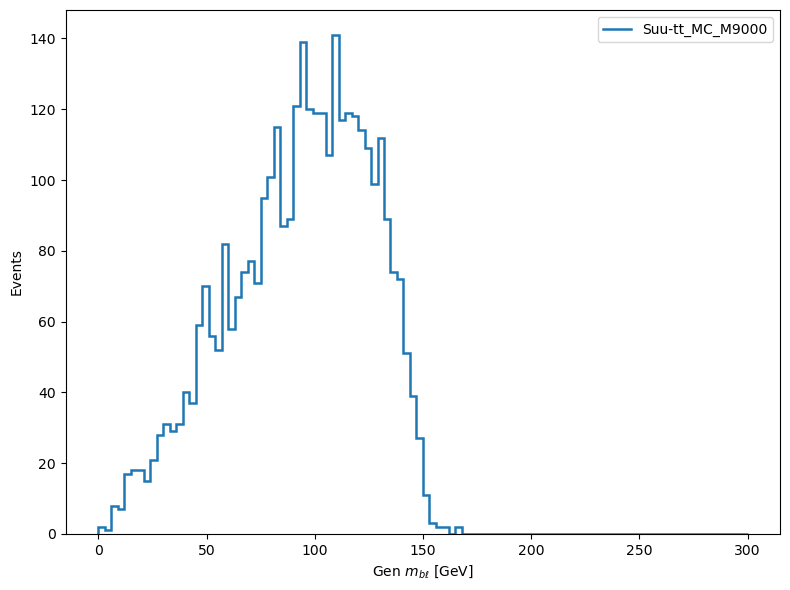

In [44]:
import matplotlib.pyplot as plt
# -------------------------------------------------
# Plot gen m_bl hist
# -------------------------------------------------
mt_assumed = 172.5
mw_assumed = 80.3
mbl_endpoint = np.sqrt(mt_assumed**2 - mw_assumed**2)

plt.figure(figsize=(8, 6))

for dsname, result in ds_all.items():
    h_mbl = result["mbl"]

    # Exclude underflow and overflow from the plotted bins.
    values = h_mbl.values(flow=False)
    edges = h_mbl.axes[0].edges

    plt.stairs(
        values,
        edges,
        label=dsname,
        linewidth=1.8,
    )

    # Print useful checks.
    values_with_flow = h_mbl.values(flow=True)

    print(f"{dsname}:")
    print(f"  entries inside histogram range = {np.sum(values):.0f}")
    print(f"  underflow = {values_with_flow[0]:.0f}")
    print(f"  overflow  = {values_with_flow[-1]:.0f}")

#plt.axvline(
#    mbl_endpoint,
#    linestyle="--",
#    label=rf"$\sqrt{{m_t^2-m_W^2}}={mbl_endpoint:.1f}$ GeV",
#)

plt.xlabel(r"Gen $m_{b\ell}$ [GeV]")
plt.ylabel("Events")
#plt.title(r"gen $m_{b\ell}$")
plt.legend()
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Suu-tt_MC_M9000:
  entries in range = 3482
  underflow        = 0
  overflow         = 0
  peak-bin center  = 79.500 GeV
  finite-range mean = 79.928 GeV


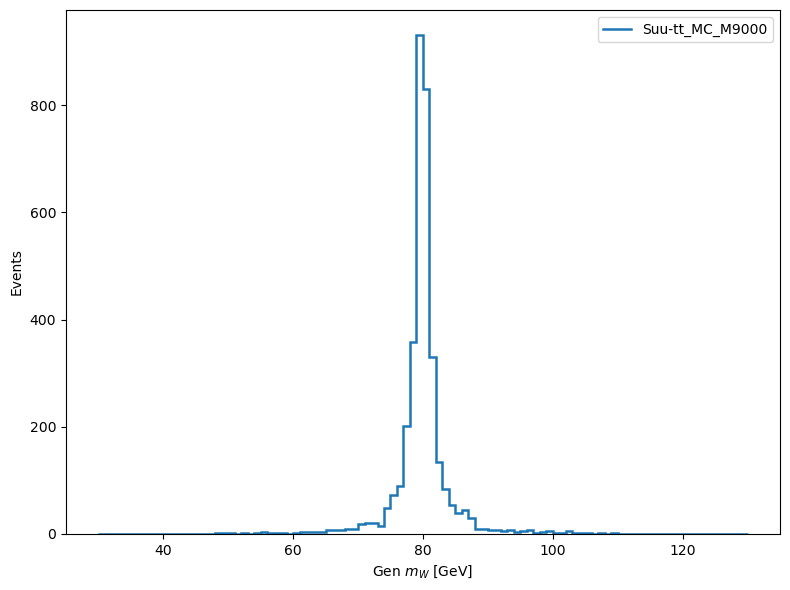

In [45]:
# -------------------------------------------------
# Plot gen W-mass distribution
# -------------------------------------------------
plt.figure(figsize=(8, 6))

for dsname, result in ds_all.items():
    h_mW = result["h_mW"]

    values = h_mW.values(flow=False)
    values_with_flow = h_mW.values(flow=True)
    edges = h_mW.axes[0].edges
    centers = 0.5 * (
        edges[:-1] + edges[1:]
    )

    total_in_range = np.sum(values)

    # Normalize to one 
    #if total_in_range > 0:
    #    plot_values = values / total_in_range
    #else:
    #    plot_values = values
    plot_values = values

    plt.stairs(
        plot_values,
        edges,
        linewidth=1.8,
        label=dsname,
    )

    if total_in_range > 0:
        mode = centers[np.argmax(values)]
        mean = np.average(
            centers,
            weights=values,
        )
    else:
        mode = np.nan
        mean = np.nan

    print(f"{dsname}:")
    print(f"  entries in range = {total_in_range:.0f}")
    print(f"  underflow        = {values_with_flow[0]:.0f}")
    print(f"  overflow         = {values_with_flow[-1]:.0f}")
    print(f"  peak-bin center  = {mode:.3f} GeV")
    print(f"  finite-range mean = {mean:.3f} GeV")

#plt.axvline(
#    80.3,
#    color="black",
#    linestyle="--",
#    linewidth=1.4,
#    label=r"Current nominal input: $m_W=80.3$ GeV",
#)

plt.xlabel(r"Gen $m_W$ [GeV]")
plt.ylabel("Events")
#plt.title("Generator-level W-mass distribution")
#plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

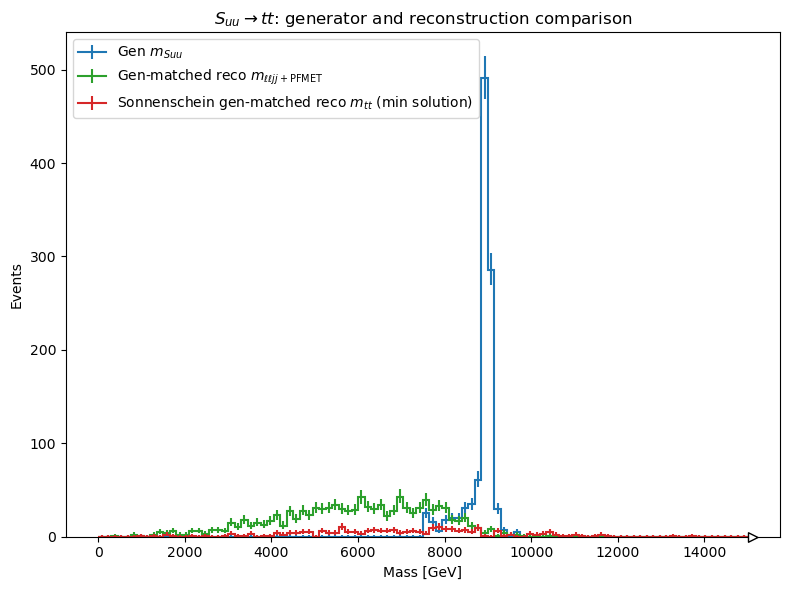

In [46]:
from coffea.util import load
import matplotlib.pyplot as plt


# -----------------------------
# Load old 2DAlphabet output
# -----------------------------

#out = load(
#    "/home/cms-jovyan/Suu_tt_analysis/ttbardileptonic/"
#    "run3_outputs_sig/test_sig_SuuToTT_M8000_2024_MC_all_local.coffea"
#)


# Old analysis reconstruction
#h_mtt_2da = out["Mlljjm"][
#    {
#        "dataset": "SuuToTT_M8000_2024_MC",
#        "systematic": "nominal",
#        "subChannel": sum,
#        "category": sum,
#    }
#]


# -----------------------------
# New reconstruction study
# -----------------------------

h_mSuu_gen = ds_all["Suu-tt_MC_M9000"]["mSuu"]

h_mtt_match = ds_all["Suu-tt_MC_M9000"]["mtt_rec"]

h_mtt_sonn = ds_all["Suu-tt_MC_M9000"]["mtt_sonn"]


# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 6))


h_mSuu_gen.plot1d(
    ax=ax,
    label=r"Gen $m_{Suu}$",
    color="tab:blue",
)


#h_mtt_2da.plot1d(
#    ax=ax,
#    label=r"2DAlphabet reco $m_{\ell\ell jj+\mathrm{PFMET}}$",
#)


h_mtt_match.plot1d(
    ax=ax,
    label=r"Gen-matched reco $m_{\ell\ell jj+\mathrm{PFMET}}$",
    color="tab:green",
)


h_mtt_sonn.plot1d(
    ax=ax,
    label=r"Sonnenschein gen-matched reco $m_{tt}$ (min solution)",
    color="tab:red",
)


ax.set_xlabel(r"Mass [GeV]")
ax.set_ylabel("Events")

ax.set_title(
    r"$S_{uu}\rightarrow tt$: generator and reconstruction comparison"
)

ax.legend()
#plt.ylim(0,30)
plt.tight_layout()
plt.show()

In [47]:
import numpy as np

def print_hist_counts(name, h):
    values_flow = h.values(flow=True)

    underflow = values_flow[0]
    in_range = np.sum(values_flow[1:-1])
    overflow = values_flow[-1]
    total = np.sum(values_flow)

    print(f"{name}:")
    print(f"  underflow = {underflow}")
    print(f"  in range  = {in_range}")
    print(f"  overflow  = {overflow}")
    print(f"  total     = {total}")


print_hist_counts("Gen-matched rough reco", h_mtt_match)
print_hist_counts("Sonnenschein", h_mtt_sonn)

n_match = np.sum(h_mtt_match.values(flow=True))
n_sonn = np.sum(h_mtt_sonn.values(flow=True))

print(f"\nSonnenschein passing fraction = {n_sonn / n_match:.3f}")

Gen-matched rough reco:
  underflow = 0.0
  in range  = 1052.0
  overflow  = 0.0
  total     = 1052.0
Sonnenschein:
  underflow = 0.0
  in range  = 232.0
  overflow  = 1.0
  total     = 233.0

Sonnenschein passing fraction = 0.221


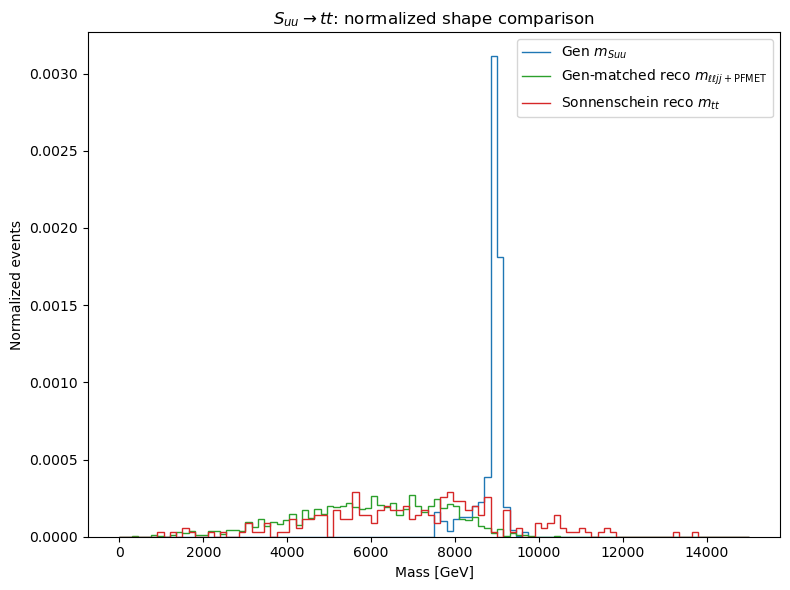

In [48]:
def plot_normalized_hist(ax, h, label, color=None):
    values = np.asarray(h.values(flow=False), dtype=float)
    edges = np.asarray(h.axes[0].edges, dtype=float)
    widths = np.diff(edges)

    # Integral of the histogram
    area = np.sum(values * widths)

    if area > 0:
        density = values / area
    else:
        density = values

    ax.stairs(
        density,
        edges,
        label=label,
        color=color,
    )

fig, ax = plt.subplots(figsize=(8, 6))

plot_normalized_hist(ax, h_mSuu_gen,  r"Gen $m_{Suu}$", color="tab:blue")
# plot_normalized_hist(ax, h_mtt_2da,   r"2DAlphabet reco $m_{\ell\ell jj+\mathrm{PFMET}}$", color="tab:orange")
plot_normalized_hist(ax, h_mtt_match, r"Gen-matched reco $m_{\ell\ell jj+\mathrm{PFMET}}$", color="tab:green")
plot_normalized_hist(ax, h_mtt_sonn,  r"Sonnenschein reco $m_{tt}$", color="tab:red")

ax.set_xlabel("Mass [GeV]")
ax.set_ylabel("Normalized events")
ax.set_title(r"$S_{uu}\to tt$: normalized shape comparison")
ax.legend()

plt.tight_layout()
plt.show()